In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from causal_mp import mp_causal_density, mp_causal_density_diagnostic, mp_causal_density_zi, mp_causal_density_zi_diagnostic
from causal_mp_iv import mp_density_iv, mp_compliers

## The effect of Zinc supplementation on the duration of the common cold

In [2]:
# load data
d = pd.read_csv("Data/ZnAcet.csv")

y = d.Duration.values
x = d.Zinc.values
w = np.ones(len(y))

# compute standardisation parameters and standardise y
mu_y = y.mean()
sig_y = y.std()
y_std = (y - mu_y) / sig_y

# run analysis — grid on standardised scale
T = 5000
B = 500

y_grid_orig = np.linspace(0, 18, 50)
y_grid_std = (y_grid_orig - mu_y) / sig_y

# single learner approach
res = mp_causal_density_diagnostic(y_std, x, w, y_grid_std, B, T)

# twin learner approach
res_t = mp_causal_density_diagnostic(y_std, x, w, y_grid_std, B, T, learner="t")

Compiling...
Compilation time: 2.512s
Optimizing...
Optimization time: 0.775s
Fitting...
Fit time: 0.017s
Optimised rho:  0.60132074
Optimised rho_x:  [0.8401232  0.00619007]
Prequential log-likelihood:  -1.2659235000610352
Predicting...
Prediction time: 0.544s
Diagnostic resampling...
Compiling...
Compilation time: 2.251s
Optimizing...
Optimization time: 0.299s
Fitting...
Fit time: 0.005s
Optimised rho for x=0:  0.6723132
Optimised rho_x for x=0:  [0.0008721]
Prequential log-likelihood for x=0:  -1.473677396774292
Predicting...
Prediction time: 0.481s
Diagnostic resampling for x=0...
Compiling...
Compilation time: 2.176s
Optimizing...
Optimization time: 0.242s
Fitting...
Fit time: 0.007s
Optimised rho for x=1:  0.7135914
Optimised rho_x for x=1:  [0.00702757]
Prequential log-likelihood for x=1:  -1.0683248043060303
Predicting...
Prediction time: 0.484s
Diagnostic resampling for x=1...


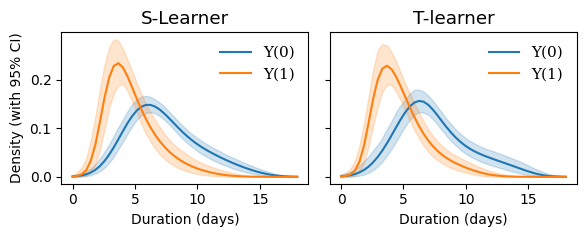

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True)

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

# --- Panel 1: S-Learner ---
ax = axes[0]
ax.plot(y_grid_orig, res['x_0']['mean'] / sig_y, label="Y(0)", color='tab:blue')
ax.fill_between(y_grid_orig, res['x_0']['low'] / sig_y, res['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)
ax.plot(y_grid_orig, res['x_1']['mean'] / sig_y, label="Y(1)", color='tab:orange')
ax.fill_between(y_grid_orig, res['x_1']['low'] / sig_y, res['x_1']['high'] / sig_y, color='tab:orange', alpha=0.2)
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Density (with 95% CI)")
ax.set_title("S-Learner")
ax.legend(frameon=False)

# --- Panel 2: T-learner ---
ax = axes[1]
ax.plot(y_grid_orig, res_t['x_0']['mean'] / sig_y, label="Y(0)", color='tab:blue')
ax.fill_between(y_grid_orig, res_t['x_0']['low'] / sig_y, res_t['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)
ax.plot(y_grid_orig, res_t['x_1']['mean'] / sig_y, label="Y(1)", color='tab:orange')
ax.fill_between(y_grid_orig, res_t['x_1']['low'] / sig_y, res_t['x_1']['high'] / sig_y, color='tab:orange', alpha=0.2)
ax.set_xlabel("Duration (days)")
ax.set_title("T-learner")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('Figures/ZincExample.pdf', dpi=300, bbox_inches='tight')
plt.show()

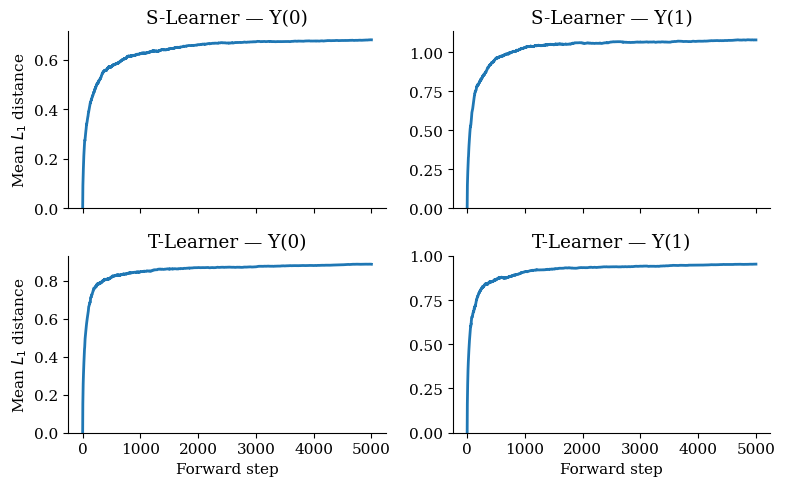

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for row, (res_d, name) in enumerate([(res, "S-Learner"), (res_t, "T-Learner")]):
    for col, (xi, lab) in enumerate([(0, "Y(0)"), (1, "Y(1)")]):
        ax = axs[row, col]
        l1 = res_d["l1_trajectory"][:, :, xi]
        steps = np.arange(l1.shape[1])
        ax.plot(steps, l1.mean(axis=0), linewidth=2)
        ax.set_ylim(bottom=0)
        if row == 1:
            ax.set_xlabel("Forward step")
        if col == 0:
            ax.set_ylabel(r"Mean $L_1$ distance")
        ax.set_title(f"{name} — {lab}")

plt.tight_layout()
plt.show()

## A Vitamin A supplementation trial

In [2]:
# Sommer & Zeger Vitamin A Study Dataset
# Create the dataset from contingency table
data_counts = [
    (0, 0, 0, 74),      # Assigned: No, Received: No, Outcome: Died
    (0, 0, 1, 11514),   # Assigned: No, Received: No, Outcome: Survived
    (1, 0, 0, 34),      # Assigned: Yes, Received: No, Outcome: Died
    (1, 0, 1, 2385),    # Assigned: Yes, Received: No, Outcome: Survived
    (1, 1, 0, 12),      # Assigned: Yes, Received: Yes, Outcome: Died
    (1, 1, 1, 9663)     # Assigned: Yes, Received: Yes, Outcome: Survived
]

Z_data = []
X_data = []
Y_data = []

for z, x, y, count in data_counts:
    Z_data.extend([z] * count)
    X_data.extend([x] * count)
    Y_data.extend([y] * count)

Z_data = np.array(Z_data)
X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"Total observations: {len(Y_data)}")
print(f"Outcome distribution: {np.mean(Y_data):.4f}")
print(f"Treatment (X=1) rate: {np.mean(X_data):.4f}")
print(f"Instrument (Z=1) rate: {np.mean(Z_data):.4f}")

# Summary statistics by instrument assignment
print("\nSummary by Instrument Assignment:")
print(f"  Z=0: P(X=1|Z=0) = {np.mean(X_data[Z_data == 0]):.4f}")
print(f"  Z=1: P(X=1|Z=1) = {np.mean(X_data[Z_data == 1]):.4f}")

Total observations: 23682
Outcome distribution: 0.9949
Treatment (X=1) rate: 0.4085
Instrument (Z=1) rate: 0.5107

Summary by Instrument Assignment:
  Z=0: P(X=1|Z=0) = 0.0000
  Z=1: P(X=1|Z=1) = 0.8000


In [10]:
# Run mp_compliers with Bayesian bootstrap approach
# For binary outcomes with complier identification
B_post = 1000  # Number of posterior samples
T_fwd = 100_000

np.random.seed(42)
results_compliers = mp_compliers(Y_data, X_data, Z_data, B_post, T_fwd, n_checkpoints=1000)

In [11]:
# report the complier proportion
print("90% CI for the complier proportion: ", np.quantile(results_compliers['Complier'][:, -1], [0.05, 0.95]))

# report the LATE estimates
print(
    "90% CI for the LATE (per 1000 individuals): ",
    1000 * np.quantile(results_compliers['Treatment'][:, -1] - results_compliers['Control'][:, -1], [0.05, 0.95])
)

90% CI for the complier proportion:  [0.79476686 0.80562548]
90% CI for the LATE (per 1000 individuals):  [1.47459808 4.93686316]


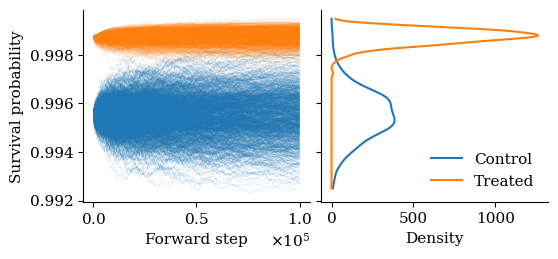

In [12]:
from scipy.stats import gaussian_kde

p_y0_samples = results_compliers['Control'][:, -1]
p_y1_samples = results_compliers['Treatment'][:, -1]

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5), sharey=True,
                         gridspec_kw={'wspace': 0.05})

steps = results_compliers['checkpoints']

# --- Panel 1: All sequences ---
ax = axes[0]
for samples, color in [
    (results_compliers['Control'], 'tab:blue'),
    (results_compliers['Treatment'], 'tab:orange'),
]:
    for b in range(samples.shape[0]):
        ax.plot(steps, samples[b], color=color, alpha=0.2, linewidth=0.3)
ax.set_xlabel("Forward step")
ax.set_ylabel("Survival probability")
fmt = ticker.ScalarFormatter(useMathText=True)
fmt.set_powerlimits((0, 0))
ax.xaxis.set_major_formatter(fmt)

# --- Panel 2: KDE density ---
ax = axes[1]
y_grid_kde = np.linspace(
    min(p_y0_samples.min(), p_y1_samples.min()),
    max(p_y0_samples.max(), p_y1_samples.max()),
    200,
)
for samples, color, label in [
    (p_y0_samples, 'tab:blue', 'Control'),
    (p_y1_samples, 'tab:orange', 'Treated'),
]:
    kde = gaussian_kde(samples)
    ax.plot(kde(y_grid_kde), y_grid_kde, color=color, label=label)
ax.set_xlabel('Density')
ax.legend(frameon=False, loc='lower right')

plt.savefig("Figures/Sommer_Zeger_Results.pdf", bbox_inches='tight')
plt.show()

## Lalonde

In [2]:
# load data
d = pd.read_csv("Data/lalonde.csv")

y = d.re78.values
x = d.treat.values
w = d[['age', 'educ', 'hisp', 'black', 'married', 'nodegr', 're74', 're75', 'u74', 'u75']].values

print("Number of treated and control observations:", x.sum(), d.shape[0] - x.sum())

Number of treated and control observations: 185 260


In [9]:

# compute standardisation parameters and standardise y
mu_y = y.mean()
sig_y = y.std()
y_std = (y - mu_y) / sig_y
y0_std = (0 - mu_y) / sig_y  # standardised location of the point mass at re78 = 0

w_std = (w - w.mean(axis=0)) / w.std(axis=0)

# run analysis on standardised grid
T = 2000
B = 200

y_grid_orig = np.linspace(0, 25000, 50)
y_grid_std = (y_grid_orig - mu_y) / sig_y

# Counterfactual outcomes among treated Y(0)|X = 1 and Y(1)|X = 1. re78 has a large point
# mass at zero (unemployed participants), which corrupts the continuous copula recursion if
# fed through it directly -- see the "Zero-inflated mixture" discussion below -- so we use
# the zero-inflated mixture model: P(Y=0|x,w) via a recursively updated logistic regression,
# plus a copula-regression model for Y|Y!=0,x,w fit on the non-zero subsample.
res_bb = mp_causal_density_zi_diagnostic(y_std, x, w_std, y_grid_std, B, T, weighting="att", y0=y0_std)

# logistic regression as comparison
res_log = mp_causal_density_zi_diagnostic(y_std, x, w_std, y_grid_std, B, T, weighting="att", x_update="logistic", y0=y0_std)


Zero-atom rate at y0=-0.8002316855737751: 0.3079 (137/445)
Compiling...
Compilation time: 0.235s
Optimizing...
Optimization time: 3.715s
Fitting...
Fit time: 0.039s
Optimised rho for continuous part (Y != y0):  0.08661853
Optimised rho_x for continuous part (Y != y0):  [0.87857693 0.10351639 0.34279203 0.01573683 0.05652124 0.01659351
 0.02084245 0.5797024  0.7176261  0.98591226 0.37318474]
Prequential log-likelihood for continuous part (Y != y0):  -1.3728885650634766
Predicting...
Prediction time: 1.89s
Zero-atom rate at y0=-0.8002316855737751: 0.3079 (137/445)
Compiling...
Compilation time: 0.194s
Optimizing...
Optimization time: 3.864s
Fitting...
Fit time: 0.041s
Optimised rho for continuous part (Y != y0):  0.08661853
Optimised rho_x for continuous part (Y != y0):  [0.87857693 0.10351639 0.34279203 0.01573683 0.05652124 0.01659351
 0.02084245 0.5797024  0.7176261  0.98591226 0.37318474]
Prequential log-likelihood for continuous part (Y != y0):  -1.3728885650634766
Predicting...
Pre

Bayesian Bootstrap — ATT posterior mean: 1365
Bayesian Bootstrap — ATT 95% CI: [-22, 2782]
Logistic — ATT posterior mean: 1456
Logistic — ATT 95% CI: [189, 2870]


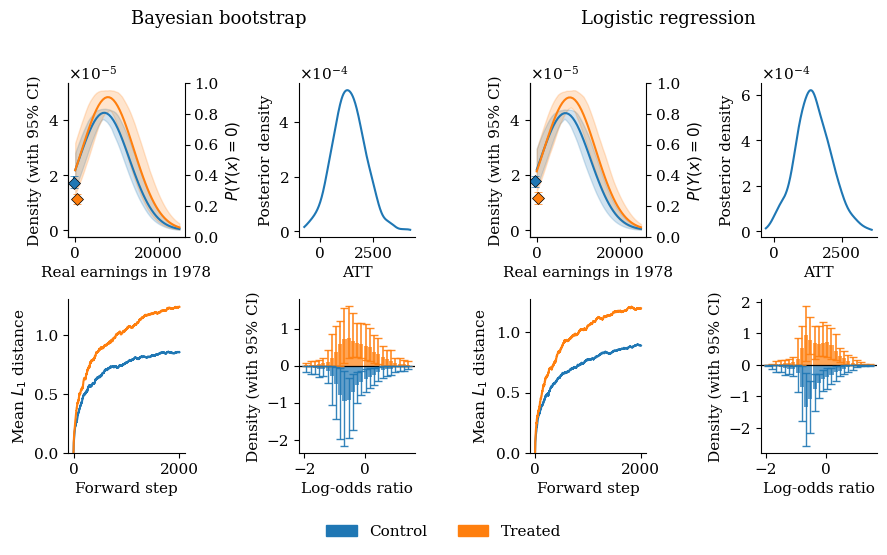

In [14]:
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

bins = np.linspace(-2, 1.5, 26)
bin_centres = 0.5 * (bins[:-1] + bins[1:])
width = bins[1] - bins[0]

def plot_lalonde_panels(res, panel_axes, y_grid_orig, sig_y, x,
                        bins=bins, bin_centres=bin_centres, width=width):
    ax_dens, ax_att, ax_l1, ax_ps = panel_axes

    # --- Counterfactual densities, with the point mass P(Y=0|x) on its own twin axis ---
    # (the point mass lives on a probability scale, not a density scale, and is typically much
    # larger in magnitude than the continuous density -- plotting both on the same axis makes
    # the continuous curve unreadable)
    ax_dens2 = ax_dens.twinx()
    ax_dens2.spines['right'].set_visible(True)  # rcParams above disables it by default
    ax_dens2.spines['top'].set_visible(False)
    for xi, color, offset in [(0, "tab:blue", -400), (1, "tab:orange", 400)]:
        p0 = res['p0'][f'x_{xi}']
        scale = (1 - p0['mean']) / sig_y
        mean_d = res[f'x_{xi}']['mean'] * scale
        low_d  = res[f'x_{xi}']['low'] * scale
        high_d = res[f'x_{xi}']['high'] * scale

        ax_dens.plot(y_grid_orig, mean_d, color=color)
        ax_dens.fill_between(y_grid_orig, low_d, high_d, color=color, alpha=0.2)

        ax_dens2.errorbar([offset], [p0['mean']], yerr=[[p0['mean'] - p0['low']], [p0['high'] - p0['mean']]],
                          fmt='D', color=color, capsize=3, markersize=6,
                          markeredgecolor='black', markeredgewidth=0.5)
    ax_dens2.set_ylim(0, 1)

    ax_dens.set_xlabel("Real earnings in 1978")
    ax_dens.set_xticks([0, 20000])
    fmt = ticker.ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    ax_dens.yaxis.set_major_formatter(fmt)
    ax_dens.set_ylabel("Density (with 95% CI)")

    # --- ATT posterior ---
    # E[Y(x)] is a convex combination of the continuous part and the zero part: the zero part
    # contributes exactly 0 (since y0 = 0 here), but its probability p0 still matters by
    # shrinking the continuous contribution: E[Y(x)] = (1 - p0) * E[Y(x) | Y(x) != 0].
    pdfs_pos_orig = res['marginal_pdfs_pos'] / sig_y  # (B, n_x, n_y), raw per-draw, density in original units
    p0_marginal = res['p0_marginal']                  # (B, n_x), raw per-draw P(Y(x)=0)
    E_cont = np.trapezoid(y_grid_orig[None, None, :] * pdfs_pos_orig, y_grid_orig, axis=-1)  # (B, n_x)
    E_y = (1 - p0_marginal) * E_cont  # (B, n_x)
    att_samples = E_y[:, 1] - E_y[:, 0]

    kde = gaussian_kde(att_samples)
    att_grid = np.linspace(att_samples.min() - 200, att_samples.max() + 200, 300)
    ax_att.plot(att_grid, kde(att_grid), color='tab:blue')
    ax_att.set_xlabel("ATT")
    fmt2 = ticker.ScalarFormatter(useMathText=True)
    fmt2.set_powerlimits((0, 0))
    ax_att.yaxis.set_major_formatter(fmt2)
    ax_att.set_ylabel("Posterior density")

    # --- L1 convergence (continuous part only) ---
    l1 = res['l1_trajectory']
    mean_l1 = l1.mean(axis=0)
    t_axis = np.arange(mean_l1.shape[0])
    ax_l1.plot(t_axis, mean_l1[:, 0], color='tab:blue')
    ax_l1.plot(t_axis, mean_l1[:, 1], color='tab:orange')
    ax_l1.set_ylim(bottom=0)
    ax_l1.set_xlabel("Forward step")
    ax_l1.set_ylabel(r"Mean $L_1$ distance")

    # --- Propensity score histogram ---
    def _hist_density(lo_samples, x_flag, B_post):
        out = np.zeros((B_post, len(bins) - 1))
        for b in range(B_post):
            vals = lo_samples[b, x == x_flag]
            counts, _ = np.histogram(vals, bins=bins, density=True)
            out[b] = counts
        return out

    ps = res['propensity_scores']
    log_odds = np.log(np.clip(ps, 1e-6, 1 - 1e-6) / np.clip(1 - ps, 1e-6, 1 - 1e-6))
    B_post = ps.shape[0]

    hist_trt  = _hist_density(log_odds, 1, B_post)
    hist_ctrl = _hist_density(log_odds, 0, B_post)

    med_trt = np.mean(hist_trt,  axis=0)
    lo_trt  = np.quantile(hist_trt,  0.025, axis=0)
    hi_trt  = np.quantile(hist_trt,  0.975, axis=0)

    med_ctrl = np.mean(hist_ctrl, axis=0)
    lo_ctrl  = np.quantile(hist_ctrl, 0.025, axis=0)
    hi_ctrl  = np.quantile(hist_ctrl, 0.975, axis=0)

    ax_ps.axhline(0, color='black', linewidth=0.9)
    ax_ps.bar(bin_centres,  med_trt,  width=width * 0.95, color='tab:orange', alpha=0.7)
    # clip to guard against tiny negative round-off, which errorbar rejects outright
    ax_ps.errorbar(bin_centres, med_trt,
                yerr=[np.maximum(med_trt - lo_trt, 0), np.maximum(hi_trt - med_trt, 0)],
                fmt='none', color='tab:orange', capsize=3, linewidth=1.2, alpha=0.9)
    ax_ps.bar(bin_centres, -med_ctrl, width=width * 0.95, color='tab:blue', alpha=0.7)
    ax_ps.errorbar(bin_centres, -med_ctrl,
                yerr=[np.maximum(hi_ctrl - med_ctrl, 0), np.maximum(med_ctrl - lo_ctrl, 0)],
                fmt='none', color='tab:blue', capsize=3, linewidth=1.0, alpha=0.9)
    ax_ps.set_xlabel("Log-odds ratio")
    ax_ps.set_ylabel("Density (with 95% CI)")

    return att_samples, ax_dens2

fig, axes = plt.subplots(2, 4, figsize=(9, 5))

att_bb, ax2_bb = plot_lalonde_panels(res_bb, [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]],
                    y_grid_orig, sig_y, x)
ax2_bb.set_ylabel(r"$P(Y(x)=0)$")

att_log, ax2_log = plot_lalonde_panels(res_log, [axes[0, 2], axes[0, 3], axes[1, 2], axes[1, 3]],
                    y_grid_orig, sig_y, x)
ax2_log.set_ylabel(r"$P(Y(x)=0)$")

fig.text(0.25, 1.0, "Bayesian bootstrap", ha='center', va='bottom', fontsize=13)
fig.text(0.75, 1.0, "Logistic regression", ha='center', va='bottom', fontsize=13)

fig.legend(handles=[Patch(color='tab:blue', label='Control'),
                    Patch(color='tab:orange', label='Treated')],
           loc='lower center', ncol=2, frameon=False, fontsize=11,
           bbox_to_anchor=(0.5, -0.05))

for label, att in [("Bayesian Bootstrap", att_bb), ("Logistic", att_log)]:
    print(f"{label} — ATT posterior mean: {att.mean():.0f}")
    print(f"{label} — ATT 95% CI: [{np.quantile(att, 0.025):.0f}, {np.quantile(att, 0.975):.0f}]")

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('Figures/LalondeExample.pdf', dpi=300, bbox_inches='tight')
plt.show()